# Prompt U-Net Version 320 Training

# v320 — Control Experiment: v21 Architecture + v310-era Data Pipeline

**Research question:** Do the performance differences between v21 and later
models (v292–v313) come **purely from the new training data / preprocessing**?

## What is identical to v21

| Component | v21 value |
|---|---|
| **Filter schedule** | `[32, 64, 128, 256, 512]` + 1024 bottleneck |
| **Decoder** | `Conv2DTranspose` (not bilinear UpSampling) |
| **Prompt fusion** | plain `Add()` — no SE attention |
| **Augmentation** | 10 % probability per stage (photo / geo / morph) |
| **Augmentation ops** | RandomFlip, RandomRotation ±5 %, RandomZoom ±5 %, RandomTranslation ±5 %, RandomBrightness/Contrast/Noise |
| **Loss** | `binary_crossentropy` |
| **Optimizer** | `Adam` + `ExponentialDecay` (LR 1e-3, decay 0.85 / 2 000 ep) |
| **Epochs** | 3 664 |
| **Batch size** | 128 |
| **dp\_training** | 3 500 |
| **offset** | 12 |
| **max\_number\_labels** | 4 |
| **Dataset refresh** | every 75 epochs |
| **Validation loop** | every 300 epochs |

## What is different from v21 (infrastructure only)

| Component | Change |
|---|---|
| **DataGenerator** | Current `DataGenerator.py` (isotropic volumes, label-guided 128×128 patch crop, pure-numpy, fast valid-slice index) |
| **Normalization** | `universal_normalization` (CT hard-coded HU stats, MRI masked z-score with percentile clipping) |
| **Training data** | 3 datasets via `DataLoader_npz`: `nako_combined`, `total_seg_combined`, `msd_combined` |
| **`train_step()`** | Decorated with `@tf.function` (graph mode execution) |
| **`train_epoch()`** | Native `for z in train_dataset` loop (no manual `iter` / `next`) |
| **Pipeline** | Persistent `tf.data` graph (from-generator + augmentation map built once) |

## Setup

In [1]:
import os
import sys
import gc
import math as _m
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import mlflow
import tensorflow as tf

# v320: pure float32 — no mixed precision (matches v21 implicit float32)
# tf.keras.mixed_precision.set_global_policy("mixed_float16")

import logging
tf.get_logger().setLevel(logging.ERROR)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

print(f"TF  : {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")

2026-04-21 10:45:39.226732: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776761139.249455      61 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776761139.256651      61 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776761139.274238      61 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776761139.274267      61 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776761139.274304      61 computation_placer.cc:177] computation placer alr

TF  : 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Allow importing from project root
notebook_dir = Path().resolve()
project_root  = notebook_dir.parent
sys.path.insert(0, str(project_root))

from data.DataLoader_npz import DataLoader_npz
from data.DataGenerator  import DataGenerator

from utils.metrics        import dice_score_tf
from utils.visualization  import plot_result

from prompt_unet_320 import PromptUNet   # v320 architecture

## Data Loading

Three datasets — same as v310–313.

In [3]:
dataset_paths = [
    "data/train_data/nako_combined.npz",
    "data/train_data/total_seg_combined.npz",
    "data/train_data/msd_combined.npz",
]

dataloader    = DataLoader_npz(dataset_paths, val_size=0.01)
datagenerator = DataGenerator(dataloader)

print(f"Image size: {datagenerator.height} x {datagenerator.width}")


Loading NPZ dataset(s)…
Loaded 61 PIDs from /home/dpxuser/prompt-unet/data/train_data/nako_combined.npz
Loaded 45 PIDs from /home/dpxuser/prompt-unet/data/train_data/total_seg_combined.npz
Loaded 40 PIDs from /home/dpxuser/prompt-unet/data/train_data/msd_combined.npz

Final dataset size: 146 patients.

Image size: 128 x 128


## Hyperparameters

Identical to v21.

In [4]:
version           = "p_unet_320"

epochs            = 3664
batch_size        = 128
dp_training       = 3500
dp_testing        = 1000

offset            = 12
max_number_labels = 4

new_ds       = 75    # refresh training data every N epochs (v21 value)
new_val_loop = 300   # run validation every N epochs (v21 value)

## Model & Optimizer

Architecture: v21 filter schedule `[32, 64, 128, 256, 512]` + 1024 bottleneck.

LR schedule: `ExponentialDecay` — identical to v21:
- `initial_learning_rate = 0.001`
- `decay_rate = 0.85` (staircase)
- `decay_steps = steps_per_epoch × 2000`

In [5]:
# ── Build model ───────────────────────────────────────────────────────────────
model = PromptUNet(height=datagenerator.height, width=datagenerator.width)

# Warm-up forward pass to fully initialise all layers
_dummy_x = tf.random.uniform([1, datagenerator.height, datagenerator.width, 1])
_dummy_p = tf.random.uniform([1, datagenerator.height, datagenerator.width, 2])
_ = model.this([_dummy_x, _dummy_p])

print(f"Trainable params: {model.this.count_params():,}")

# ── v21 ExponentialDecay LR schedule ──────────────────────────────────────────
steps_per_epoch = dp_training // batch_size
decay_epochs    = 2000          # reduce every x epochs (v21 value)
decay_steps     = steps_per_epoch * decay_epochs

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=decay_steps,
    decay_rate=0.85,
    staircase=True,
)

model.optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

I0000 00:00:1776761357.331487      61 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46640 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:c1:00.0, compute capability: 8.6
I0000 00:00:1776761360.458664      61 cuda_dnn.cc:529] Loaded cuDNN version 91002


Trainable params: 45,628,641


## Persistent tf.data Pipeline

The pipeline graph (including `.map(augmenter)`) is built **once** here.  
When fresh training data is needed, only the numpy buffer is swapped — no TF
graph nodes accumulate over time.

The augmentation function used is the **exact v21 augmentation** (10 % per stage,
same photometric / geometric / morphological ops), accessed via `model.v21_augmentation`.

In [6]:
# ── Shared numpy buffer ───────────────────────────────────────────────────────
_buf = {"x": None, "y": None, "p": None, "m": None}

def refresh_train_data():
    """Pull fresh random training data into the numpy buffer."""
    x_np, y_np, p_np, m_np, _ = datagenerator.get_data_points_numpy(
        max_data_points   = dp_training,
        offset            = offset,
        max_number_labels = max_number_labels,
    )
    _buf["x"] = x_np
    _buf["y"] = y_np
    _buf["p"] = p_np
    _buf["m"] = m_np
    gc.collect()


def _data_gen():
    """Yields one shuffled sample at a time from the numpy buffer."""
    n       = len(_buf["x"])
    indices = np.random.permutation(n)
    for i in indices:
        yield _buf["x"][i], _buf["y"][i], _buf["p"][i], _buf["m"][i]


H, W = datagenerator.height, datagenerator.width

# ── Two-stage augmentation pipeline ──────────────────────────────────────────
#
# Stage 1  v21_augmentation_tf()  — pure TF ops (geo + photo)
#          Called directly as a .map() step in graph mode.
#          RandomRotation / RandomZoom are safe here (no EagerPyFunc wrapper).
#
# Stage 2  v21_augmentation_morph()  — scipy/numpy ops (prompt morphology)
#          Must go through tf.py_function so it runs eagerly.
#
# WHY two stages?
#   Keras's RandomRotation (and Zoom/Translation) have a TF bug where a
#   4-channel tensor processed inside tf.py_function (EagerPyFunc) causes:
#       "Expected begin, end, and strides to be 1D equal size tensors,
#        but got shapes [4], [1], and [1] instead."
#   Moving the geo augmentation to a plain .map() step avoids EagerPyFunc
#   entirely and lets TF trace the ops correctly.

def _augment_stage1(x, y, p, m):
    """Stage 1: geo + photometric augmentation — pure TF, graph-mode safe."""
    x, y, p, m = model.v21_augmentation_tf(x, y, p, m)
    x.set_shape((H, W, 1))
    y.set_shape((H, W, 1))
    p.set_shape((H, W, 2))
    return x, y, p, m


def _augment_stage2(x, y, p, m):
    """Stage 2: prompt morphological augmentation — wrapped in py_function."""
    x, y, p = tf.py_function(
        lambda xi, yi, pi: model.v21_augmentation_morph(xi, yi, pi),
        [x, y, p],
        [tf.float32, tf.float32, tf.float32],
    )
    x.set_shape((H, W, 1))
    y.set_shape((H, W, 1))
    p.set_shape((H, W, 2))
    return x, y, p, m


train_ds = (
    tf.data.Dataset.from_generator(
        _data_gen,
        output_signature=(
            tf.TensorSpec(shape=(H, W, 1), dtype=tf.float32),  # image
            tf.TensorSpec(shape=(H, W, 1), dtype=tf.float32),  # label
            tf.TensorSpec(shape=(H, W, 2), dtype=tf.float32),  # prompt
            tf.TensorSpec(shape=(),        dtype=tf.float32),  # modality
        )
    )
    .map(_augment_stage1, num_parallel_calls=tf.data.AUTOTUNE)
    .map(_augment_stage2, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

print("Pipeline ready.")


Pipeline ready.


## Training

Loop structure mirrors v21 exactly:
- Checkpoint every 8 epochs
- Validation every `new_val_loop` (300) epochs
- Dataset refresh every `new_ds` (75) epochs

Creating new Data Points ...
It took 8 seconds
Creating new Data Points ...
It took 126 seconds


E0000 00:00:1776761520.406537      61 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape infunctional_1_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-04-21 10:52:29.956555: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch    1  loss: 0.405163


2026-04-21 10:52:49.884347: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch    2  loss: 0.243515
Epoch    3  loss: 0.199714


...

2026-04-21 11:02:35.140934: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch   32  loss: 0.091217
Epoch   33  loss: 0.089623
Epoch   34  loss: 0.087669
Epoch   35  loss: 0.087506
Epoch   36  loss: 0.085763
Epoch   37  loss: 0.087118
Epoch   38  loss: 0.084882
Epoch   39  loss: 0.085708
Epoch   40  loss: 0.084387
Epoch   41  loss: 0.084480
Epoch   42  loss: 0.083163
Epoch   43  loss: 0.082370
Epoch   44  loss: 0.081892
Epoch   45  loss: 0.080472
Epoch   46  loss: 0.081705
Epoch   47  loss: 0.081241
Epoch   48  loss: 0.080340
Epoch   49  loss: 0.078645
Epoch   50  loss: 0.079939
Epoch   51  loss: 0.080036
Epoch   52  loss: 0.077844
Epoch   53  loss: 0.076601
Epoch   54  loss: 0.077265
Epoch   55  loss: 0.076112
Epoch   56  loss: 0.076186
Epoch   57  loss: 0.075755
Epoch   58  loss: 0.075991
Epoch   59  loss: 0.075503
Epoch   60  loss: 0.074586
Epoch   61  loss: 0.074447
Epoch   62  loss: 0.073881
Epoch   63  loss: 0.073839


2026-04-21 11:12:55.955369: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch   64  loss: 0.074107
Epoch   65  loss: 0.072039
Epoch   66  loss: 0.072050
Epoch   67  loss: 0.072983
Epoch   68  loss: 0.073038
Epoch   69  loss: 0.070407
Epoch   70  loss: 0.069667
Epoch   71  loss: 0.070121
Epoch   72  loss: 0.069985
Epoch   73  loss: 0.070997
Epoch   74  loss: 0.069155
Epoch   75  loss: 0.070339


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].


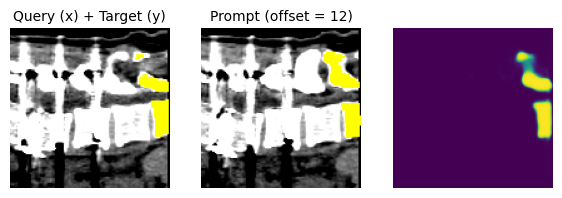

Creating new Data Points ...
It took 218 seconds
Epoch   76  loss: 0.088215
Epoch   77  loss: 0.081614
Epoch   78  loss: 0.079574
Epoch   79  loss: 0.077104
Epoch   80  loss: 0.076904
Epoch   81  loss: 0.076810
Epoch   82  loss: 0.076325
Epoch   83  loss: 0.075749
Epoch   84  loss: 0.075234
Epoch   85  loss: 0.075478
Epoch   86  loss: 0.074158
Epoch   87  loss: 0.074793
Epoch   88  loss: 0.074655
Epoch   89  loss: 0.074260
Epoch   90  loss: 0.073343
Epoch   91  loss: 0.073378
Epoch   92  loss: 0.073081
Epoch   93  loss: 0.072843
Epoch   94  loss: 0.070540
Epoch   95  loss: 0.071545
Epoch   96  loss: 0.070044
Epoch   97  loss: 0.071535
Epoch   98  loss: 0.070615
Epoch   99  loss: 0.069193
Epoch  100  loss: 0.069903
Epoch  101  loss: 0.068869
Epoch  102  loss: 0.070053
Epoch  103  loss: 0.069944
Epoch  104  loss: 0.069689
Epoch  105  loss: 0.069245
Epoch  106  loss: 0.067781
Epoch  107  loss: 0.065556
Epoch  108  loss: 0.066682
Epoch  109  loss: 0.066511
Epoch  110  loss: 0.066615
Epoch 

2026-04-21 11:38:36.466499: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch  128  loss: 0.061698
Epoch  129  loss: 0.061066
Epoch  130  loss: 0.059685
Epoch  131  loss: 0.057979
Epoch  132  loss: 0.058859
Epoch  133  loss: 0.057129
Epoch  134  loss: 0.056837
Epoch  135  loss: 0.057338
Epoch  136  loss: 0.056206
Epoch  137  loss: 0.056542
Epoch  138  loss: 0.057751
Epoch  139  loss: 0.057149
Epoch  140  loss: 0.055715
Epoch  141  loss: 0.057058
Epoch  142  loss: 0.055624
Epoch  143  loss: 0.055561
Epoch  144  loss: 0.053776
Epoch  145  loss: 0.055000
Epoch  146  loss: 0.057345
Epoch  147  loss: 0.057263
Epoch  148  loss: 0.053448
Epoch  149  loss: 0.053675
Epoch  150  loss: 0.055222


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].


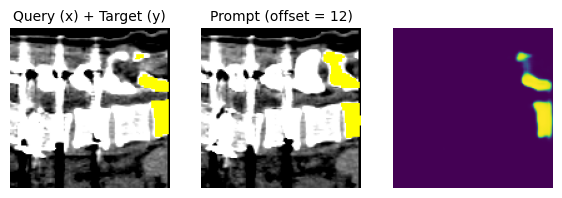

Creating new Data Points ...
It took 161 seconds
Epoch  151  loss: 0.088649
Epoch  152  loss: 0.082723
Epoch  153  loss: 0.079971
Epoch  154  loss: 0.076646
Epoch  155  loss: 0.075567
Epoch  156  loss: 0.072255
Epoch  157  loss: 0.070659
Epoch  158  loss: 0.068856
Epoch  159  loss: 0.069558
Epoch  160  loss: 0.070058
Epoch  161  loss: 0.067225
Epoch  162  loss: 0.067601
Epoch  163  loss: 0.065976
Epoch  164  loss: 0.065595
Epoch  165  loss: 0.063893
Epoch  166  loss: 0.061886
Epoch  167  loss: 0.062521
Epoch  168  loss: 0.062453
Epoch  169  loss: 0.061787
Epoch  170  loss: 0.061390
Epoch  171  loss: 0.060074
Epoch  172  loss: 0.059602
Epoch  173  loss: 0.059589
Epoch  174  loss: 0.058954
Epoch  175  loss: 0.057398
Epoch  176  loss: 0.057348
Epoch  177  loss: 0.056529
Epoch  178  loss: 0.056340
Epoch  179  loss: 0.055355
Epoch  180  loss: 0.055845
Epoch  181  loss: 0.056128
Epoch  182  loss: 0.055973
Epoch  183  loss: 0.055799
Epoch  184  loss: 0.054256
Epoch  185  loss: 0.054792
Epoch 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].


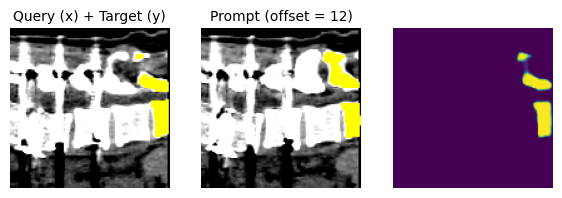

Creating new Data Points ...
It took 101 seconds
Epoch  226  loss: 0.080735
Epoch  227  loss: 0.071415
Epoch  228  loss: 0.067740
Epoch  229  loss: 0.066749
Epoch  230  loss: 0.063663
Epoch  231  loss: 0.061384
Epoch  232  loss: 0.061009
Epoch  233  loss: 0.059231
Epoch  234  loss: 0.058028
Epoch  235  loss: 0.059134
Epoch  236  loss: 0.057799
Epoch  237  loss: 0.054716
Epoch  238  loss: 0.054950
Epoch  239  loss: 0.052645
Epoch  240  loss: 0.053276
Epoch  241  loss: 0.052663
Epoch  242  loss: 0.053095
Epoch  243  loss: 0.053586
Epoch  244  loss: 0.050851
Epoch  245  loss: 0.049650
Epoch  246  loss: 0.049101
Epoch  247  loss: 0.048984
Epoch  248  loss: 0.049065
Epoch  249  loss: 0.048490
Epoch  250  loss: 0.047228
Epoch  251  loss: 0.046688
Epoch  252  loss: 0.048287
Epoch  253  loss: 0.047034
Epoch  254  loss: 0.047319
Epoch  255  loss: 0.046922


2026-04-21 12:26:20.378076: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch  256  loss: 0.046738
Epoch  257  loss: 0.045114
Epoch  258  loss: 0.044326
Epoch  259  loss: 0.045169
Epoch  260  loss: 0.045619
Epoch  261  loss: 0.043479
Epoch  262  loss: 0.044319
Epoch  263  loss: 0.045028
Epoch  264  loss: 0.043776
Epoch  265  loss: 0.043788
Epoch  266  loss: 0.043014
Epoch  267  loss: 0.043151
Epoch  268  loss: 0.043622
Epoch  269  loss: 0.043076
Epoch  270  loss: 0.042507
Epoch  271  loss: 0.042882
Epoch  272  loss: 0.041439
Epoch  273  loss: 0.040808
Epoch  274  loss: 0.041936
Epoch  275  loss: 0.041065
Epoch  276  loss: 0.040977
Epoch  277  loss: 0.040559
Epoch  278  loss: 0.041104
Epoch  279  loss: 0.040686
Epoch  280  loss: 0.040067
Epoch  281  loss: 0.041271
Epoch  282  loss: 0.040500
Epoch  283  loss: 0.040958
Epoch  284  loss: 0.040360
Epoch  285  loss: 0.039484
Epoch  286  loss: 0.038693
Epoch  287  loss: 0.039293
Epoch  288  loss: 0.039018
Epoch  289  loss: 0.038886
Epoch  290  loss: 0.038718
Epoch  291  loss: 0.039717
Epoch  292  loss: 0.038531
E

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].


  Validation loss: 0.3116


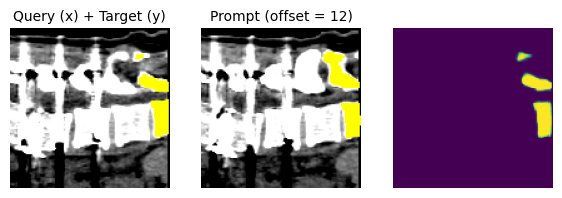

Creating new Data Points ...
It took 138 seconds
Epoch  301  loss: 0.074028
Epoch  302  loss: 0.063298
Epoch  303  loss: 0.060694
Epoch  304  loss: 0.058513
Epoch  305  loss: 0.054993
Epoch  306  loss: 0.053382
Epoch  307  loss: 0.051297
Epoch  308  loss: 0.050886
Epoch  309  loss: 0.049546
Epoch  310  loss: 0.047414
Epoch  311  loss: 0.046458
Epoch  312  loss: 0.045437
Epoch  313  loss: 0.044567
Epoch  314  loss: 0.044625
Epoch  315  loss: 0.042883
Epoch  316  loss: 0.042737
Epoch  317  loss: 0.042112
Epoch  318  loss: 0.042022
Epoch  319  loss: 0.041698
Epoch  320  loss: 0.042157
Epoch  321  loss: 0.040191
Epoch  322  loss: 0.039234
Epoch  323  loss: 0.039136
Epoch  324  loss: 0.039682
Epoch  325  loss: 0.039170
Epoch  326  loss: 0.039625
Epoch  327  loss: 0.039530
Epoch  328  loss: 0.038515
Epoch  329  loss: 0.037688
Epoch  330  loss: 0.037407
Epoch  331  loss: 0.037516
Epoch  332  loss: 0.037454
Epoch  333  loss: 0.036357
Epoch  334  loss: 0.036403
Epoch  335  loss: 0.036429
Epoch 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].


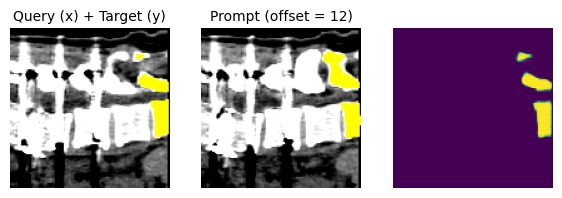

Creating new Data Points ...
It took 134 seconds
Epoch  376  loss: 0.075097
Epoch  377  loss: 0.065486
Epoch  378  loss: 0.062734
Epoch  379  loss: 0.059490
Epoch  380  loss: 0.056122
Epoch  381  loss: 0.054389
Epoch  382  loss: 0.053088
Epoch  383  loss: 0.052124
Epoch  384  loss: 0.051621
Epoch  385  loss: 0.050035
Epoch  386  loss: 0.047896
Epoch  387  loss: 0.047057
Epoch  388  loss: 0.046807
Epoch  389  loss: 0.045352
Epoch  390  loss: 0.045164
Epoch  391  loss: 0.045008
Epoch  392  loss: 0.043722
Epoch  393  loss: 0.046831
Epoch  394  loss: 0.044635
Epoch  395  loss: 0.043111
Epoch  396  loss: 0.042217
Epoch  397  loss: 0.041513
Epoch  398  loss: 0.040757
Epoch  399  loss: 0.040383
Epoch  400  loss: 0.040034
Epoch  401  loss: 0.039833
Epoch  402  loss: 0.039224
Epoch  403  loss: 0.039081
Epoch  404  loss: 0.039380
Epoch  405  loss: 0.039372
Epoch  406  loss: 0.038061
Epoch  407  loss: 0.038057
Epoch  408  loss: 0.037728
Epoch  409  loss: 0.038384
Epoch  410  loss: 0.037304
Epoch 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].


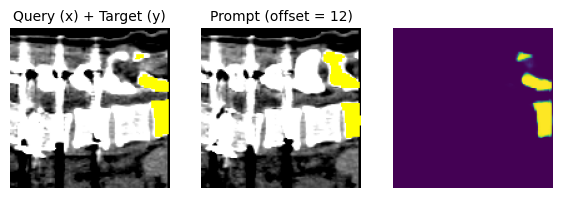

Creating new Data Points ...
It took 211 seconds
Epoch  451  loss: 0.076603
Epoch  452  loss: 0.068530
Epoch  453  loss: 0.065462
Epoch  454  loss: 0.062145
Epoch  455  loss: 0.059765
Epoch  456  loss: 0.054236
Epoch  457  loss: 0.054084
Epoch  458  loss: 0.052149
Epoch  459  loss: 0.051598
Epoch  460  loss: 0.052099
Epoch  461  loss: 0.047902
Epoch  462  loss: 0.047556
Epoch  463  loss: 0.045632
Epoch  464  loss: 0.044621
Epoch  465  loss: 0.044026
Epoch  466  loss: 0.043272
Epoch  467  loss: 0.042225
Epoch  468  loss: 0.043223
Epoch  469  loss: 0.042896
Epoch  470  loss: 0.041826
Epoch  471  loss: 0.040572
Epoch  472  loss: 0.040153
Epoch  473  loss: 0.040686
Epoch  474  loss: 0.039477
Epoch  475  loss: 0.039702
Epoch  476  loss: 0.039742
Epoch  477  loss: 0.037954
Epoch  478  loss: 0.038230
Epoch  479  loss: 0.037842
Epoch  480  loss: 0.038304
Epoch  481  loss: 0.037681
Epoch  482  loss: 0.037042
Epoch  483  loss: 0.036645
Epoch  484  loss: 0.037007
Epoch  485  loss: 0.036657
Epoch 

2026-04-21 14:01:38.336358: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch  511  loss: 0.033977
Epoch  512  loss: 0.033266
Epoch  513  loss: 0.032940
Epoch  514  loss: 0.033325
Epoch  515  loss: 0.032908
Epoch  516  loss: 0.033323
Epoch  517  loss: 0.032554
Epoch  518  loss: 0.032105
Epoch  519  loss: 0.031414
Epoch  520  loss: 0.031051
Epoch  521  loss: 0.033320
Epoch  522  loss: 0.031797
Epoch  523  loss: 0.031407
Epoch  524  loss: 0.031492
Epoch  525  loss: 0.031343


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].


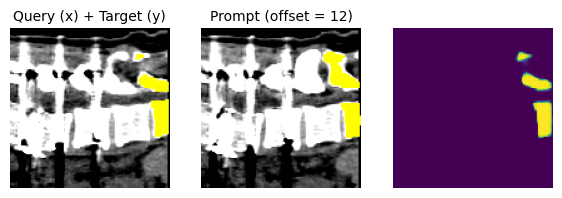

Creating new Data Points ...
It took 136 seconds
Epoch  526  loss: 0.060386
Epoch  527  loss: 0.053894
Epoch  528  loss: 0.050555
Epoch  529  loss: 0.048194
Epoch  530  loss: 0.046530
Epoch  531  loss: 0.043904
Epoch  532  loss: 0.042679
Epoch  533  loss: 0.041703
Epoch  534  loss: 0.040632
Epoch  535  loss: 0.039208
Epoch  536  loss: 0.037914
Epoch  537  loss: 0.037490
Epoch  538  loss: 0.036523
Epoch  539  loss: 0.035867
Epoch  540  loss: 0.035465
Epoch  541  loss: 0.034100
Epoch  542  loss: 0.034043
Epoch  543  loss: 0.034000
Epoch  544  loss: 0.035099
Epoch  545  loss: 0.034345
Epoch  546  loss: 0.034375
Epoch  547  loss: 0.033558
Epoch  548  loss: 0.032680
Epoch  549  loss: 0.032344
Epoch  550  loss: 0.031566
Epoch  551  loss: 0.031579
Epoch  552  loss: 0.031064
Epoch  553  loss: 0.030825
Epoch  554  loss: 0.030960
Epoch  555  loss: 0.030931
Epoch  556  loss: 0.031250
Epoch  557  loss: 0.030790
Epoch  558  loss: 0.030656
Epoch  559  loss: 0.030215
Epoch  560  loss: 0.029816
Epoch 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].


  Validation loss: 0.3372


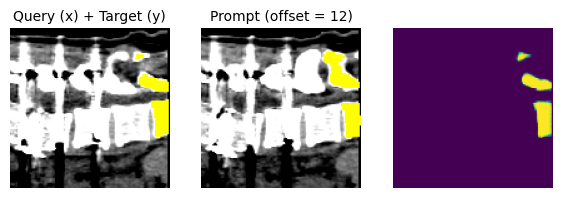

Creating new Data Points ...
It took 73 seconds
Epoch  601  loss: 0.076941
Epoch  602  loss: 0.067565
Epoch  603  loss: 0.063711
Epoch  604  loss: 0.061399
Epoch  605  loss: 0.058795
Epoch  606  loss: 0.056456
Epoch  607  loss: 0.054530
Epoch  608  loss: 0.053570
Epoch  609  loss: 0.052708
Epoch  610  loss: 0.052240
Epoch  611  loss: 0.049868
Epoch  612  loss: 0.048588
Epoch  613  loss: 0.048283
Epoch  614  loss: 0.046620
Epoch  615  loss: 0.045543
Epoch  616  loss: 0.045279
Epoch  617  loss: 0.044970
Epoch  618  loss: 0.044558
Epoch  619  loss: 0.043585
Epoch  620  loss: 0.043234
Epoch  621  loss: 0.042187
Epoch  622  loss: 0.042557
Epoch  623  loss: 0.042754
Epoch  624  loss: 0.042718
Epoch  625  loss: 0.041945
Epoch  626  loss: 0.041533
Epoch  627  loss: 0.040901
Epoch  628  loss: 0.040949
Epoch  629  loss: 0.040643
Epoch  630  loss: 0.040459
Epoch  631  loss: 0.040655
Epoch  632  loss: 0.039918
Epoch  633  loss: 0.039690
Epoch  634  loss: 0.039471
Epoch  635  loss: 0.038799
Epoch  

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..5.0].


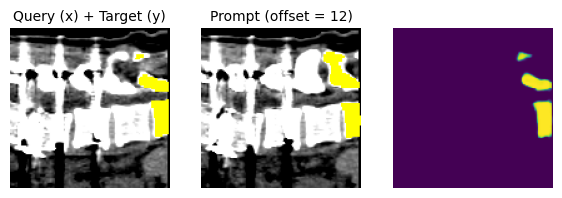

Creating new Data Points ...
It took 268 seconds
Epoch  676  loss: 0.091989
Epoch  677  loss: 0.072940
Epoch  678  loss: 0.068958
Epoch  679  loss: 0.064862
Epoch  680  loss: 0.060930
Epoch  681  loss: 0.057889
Epoch  682  loss: 0.054220
Epoch  683  loss: 0.052159
Epoch  684  loss: 0.050309
Epoch  685  loss: 0.051260
Epoch  686  loss: 0.048692
Epoch  687  loss: 0.046219
Epoch  688  loss: 0.044492
Epoch  689  loss: 0.043917
Epoch  690  loss: 0.043441
Epoch  691  loss: 0.041319
Epoch  692  loss: 0.040598
Epoch  693  loss: 0.041021
Epoch  694  loss: 0.040430
Epoch  695  loss: 0.039359
Epoch  696  loss: 0.039773
Epoch  697  loss: 0.039591
Epoch  698  loss: 0.038060
Epoch  699  loss: 0.039464


In [ ]:
def fit(epochs):
    mlflow.set_experiment(version)

    with mlflow.start_run():

        mlflow.log_params({
            "batch_size"         : batch_size,
            "max_number_labels"  : max_number_labels,
            "num_epochs"         : epochs,
            "dp_training"        : dp_training,
            "offset"             : offset,
            "loss_function"      : "binary_crossentropy",
            "lr_initial"         : 0.001,
            "lr_decay_rate"      : 0.85,
            "lr_decay_epochs"    : decay_epochs,
            "trainable_params"   : model.this.count_params(),
            "architecture"       : "v21_exact",
            "filter_schedule"    : "[32,64,128,256,512]+1024",
            "decoder"            : "Conv2DTranspose",
            "augmentation"       : "v21_10pct",
            "data_pipeline"      : "DataLoader_npz+DataGenerator_current",
            "normalization"      : "universal_normalization",
            "train_step"         : "graph_mode_tf.function",
            "train_epoch"        : "native_for_loop",
            "datasets"           : "nako+total_seg+msd",
        })

        # ── Validation dataset (built once, no augmentation) ───────────────────
        val_x, val_y, val_p, val_m, _ = datagenerator.get_val_data_points_numpy(
            max_data_points   = dp_testing,
            offset            = offset,
            max_number_labels = max_number_labels,
        )
        test_ds = (
            tf.data.Dataset.from_tensor_slices((val_x, val_y, val_p, val_m))
            .batch(1)
        )

        # ── Prime the training buffer before the loop ──────────────────────────
        refresh_train_data()

        for epoch in range(epochs):

            model.train_loss.reset_state()

            # Log learning rate
            lr = model.optimizer.learning_rate
            if isinstance(lr, tf.keras.optimizers.schedules.LearningRateSchedule):
                lr = float(lr(epoch * steps_per_epoch))
            else:
                lr = float(lr.numpy())
            mlflow.log_metric("learning_rate", lr, step=epoch)

            # Checkpoint every 8 epochs
            if epoch % 8 == 0 and epoch != 0:
                model.this.save(f"{version}.keras")

            # Validation every new_val_loop epochs
            if epoch % new_val_loop == 0 and epoch != 0:
                total_dice = 0.0
                for z in test_ds:
                    pred = model.this([z[0], z[2]], training=False)
                    total_dice += float(dice_score_tf(z[1][..., 0:1], pred))
                val_loss = 1.0 - total_dice / dp_testing
                mlflow.log_metric("validation_loss", val_loss, step=epoch)
                print(f"  Validation loss: {val_loss:.4f}")

            # Refresh training data every new_ds epochs
            if epoch % new_ds == 0 and epoch != 0:
                # Visualise one validation prediction
                z_test = next(iter(test_ds))
                pred   = model.this([z_test[0], z_test[2]], training=False)
                plot_result(z_test[0][0], z_test[1][0], z_test[2][0], pred[0], offset, "")

                # Swap numpy buffer — pipeline graph stays intact
                refresh_train_data()

            # Train one epoch (native for-loop, graph-mode train_step)
            model.train_epoch(train_dataset=train_ds)

            epoch_loss = float(model.train_loss.result())
            print(f"Epoch {epoch + 1:>4d}  loss: {epoch_loss:.6f}")
            mlflow.log_metric("train_loss", epoch_loss, step=epoch)


fit(epochs)